# GANA Multi-Seed Sanity Check

**Goal:** Verify that GANA's Phase 1 low-data wins are robust across random seeds, not seed luck.

**Setup:**
- One winning Phase 1 config: 5% MNIST, ed=16, gw=0.2, r=1.5, hidden=[256, 128]
- Three variants: GANA, GANA-ablated, MLP-baseline (parameter-matched)
- 10 seeds (0-9) per variant = 30 runs total
- ~45 min on T4

**Outcomes:**
- **Strong:** GANA wins 8+/10 vs MLP, non-overlapping CIs -> effect is real
- **Weak:** GANA wins 6-7/10, overlapping CIs -> effect is small/noisy
- **None:** GANA wins 4-6/10 -> Phase 1 wins were seed luck

Also tests: does GANA beat GANA-ablated at low data? If yes, curvature is doing real work in low-data regimes (despite not mattering at full data).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import time, random, json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_full = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_set, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print(f'Full train: {len(train_full)}, Test: {len(test_set)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 491kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.46MB/s]

Full train: 60000, Test: 10000


In [3]:
class GANALayer(nn.Module):
    def __init__(self, in_dim, out_dim, embedding_dim=16, neighbor_radius=1.5, geom_weight=0.2):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.positions = nn.Parameter(torch.randn(out_dim, embedding_dim) * 0.5)
        self.neighbor_radius = neighbor_radius
        self.geom_weight = geom_weight

    def compute_curvature_modulation(self, activations):
        with torch.no_grad():
            dists = torch.cdist(self.positions, self.positions)
            mask = (dists < self.neighbor_radius) & (dists > 1e-6)
            inv_dist = torch.where(mask, 1.0 / (dists + 1e-6), torch.zeros_like(dists))
            row_sum = inv_dist.sum(dim=1, keepdim=True).clamp(min=1e-6)
            weights = inv_dist / row_sum
        local_mean = activations @ weights.t()
        curvature = activations - local_mean
        return activations - self.geom_weight * curvature

    def forward(self, x):
        a = self.linear(x)
        if self.geom_weight > 0:
            a = self.compute_curvature_modulation(a)
        return F.relu(a)

class GANAModel(nn.Module):
    def __init__(self, hidden_dims=[256, 128], num_classes=10, embedding_dim=16, neighbor_radius=1.5, geom_weight=0.2):
        super().__init__()
        layers = []
        in_dim = 28 * 28
        for h in hidden_dims:
            layers.append(GANALayer(in_dim, h, embedding_dim, neighbor_radius, geom_weight))
            in_dim = h
        self.hidden = nn.ModuleList(layers)
        self.classifier = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.hidden:
            x = layer(x)
        return self.classifier(x)

class MLPBaseline(nn.Module):
    """Parameter-matched MLP. GANA adds 256*16 + 128*16 = 6144 params from positions.
    To match, we slightly widen the MLP hidden layers."""
    def __init__(self, hidden_dims=[266, 138], num_classes=10):
        super().__init__()
        layers = []
        in_dim = 28 * 28
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        self.hidden = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.classifier(self.hidden(x.view(x.size(0), -1)))

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Sanity check param counts
g = GANAModel()
m = MLPBaseline()
print(f'GANA params: {count_params(g)}')
print(f'MLP params:  {count_params(m)}')

GANA params: 241290
MLP params:  247046


In [4]:
def make_low_data_loader(fraction, seed, batch_size=64):
    """Stratified-ish subset: take first `fraction` of training data with seeded shuffle."""
    rng = np.random.default_rng(seed)
    n = int(len(train_full) * fraction)
    indices = rng.permutation(len(train_full))[:n]
    subset = Subset(train_full, indices.tolist())
    return DataLoader(subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

def set_all_seeds(s):
    torch.manual_seed(s); np.random.seed(s); random.seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

def train_and_eval(model, train_loader, epochs=15, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_acc = 0.0
    for ep in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward(); opt.step()
        sched.step()
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                correct += (model(x).argmax(1) == y).sum().item()
                total += y.size(0)
        acc = correct / total
        best_acc = max(best_acc, acc)
    return best_acc

In [5]:
FRACTION = 0.05  # 5% MNIST (3000 samples)
SEEDS = list(range(10))
EPOCHS = 15

results = {'gana': [], 'gana_abl': [], 'mlp': []}

t_start = time.time()
for seed in SEEDS:
    print(f'\n========== SEED {seed} ==========')
    loader = make_low_data_loader(FRACTION, seed)

    # GANA
    set_all_seeds(seed)
    model = GANAModel(geom_weight=0.2)
    t0 = time.time()
    acc = train_and_eval(model, loader, epochs=EPOCHS)
    results['gana'].append(acc)
    print(f'  GANA       acc={acc:.4f}  ({time.time()-t0:.1f}s)')

    # GANA-ablated
    set_all_seeds(seed)
    model = GANAModel(geom_weight=0.0)
    t0 = time.time()
    acc = train_and_eval(model, loader, epochs=EPOCHS)
    results['gana_abl'].append(acc)
    print(f'  GANA_abl   acc={acc:.4f}  ({time.time()-t0:.1f}s)')

    # MLP
    set_all_seeds(seed)
    model = MLPBaseline()
    t0 = time.time()
    acc = train_and_eval(model, loader, epochs=EPOCHS)
    results['mlp'].append(acc)
    print(f'  MLP        acc={acc:.4f}  ({time.time()-t0:.1f}s)')

print(f'\nTotal time: {(time.time()-t_start)/60:.1f} min')


========== SEED 0 ==========
  GANA       acc=0.9286  (39.7s)
  GANA_abl   acc=0.9313  (36.5s)
  MLP        acc=0.9321  (37.6s)

========== SEED 1 ==========
  GANA       acc=0.9306  (37.9s)
  GANA_abl   acc=0.9341  (36.8s)
  MLP        acc=0.9363  (36.1s)

========== SEED 2 ==========
  GANA       acc=0.9322  (37.5s)
  GANA_abl   acc=0.9343  (36.6s)
  MLP        acc=0.9366  (37.3s)

========== SEED 3 ==========
  GANA       acc=0.9288  (38.1s)
  GANA_abl   acc=0.9305  (37.4s)
  MLP        acc=0.9312  (37.0s)

========== SEED 4 ==========
  GANA       acc=0.9324  (38.8s)
  GANA_abl   acc=0.9354  (37.3s)
  MLP        acc=0.9354  (37.2s)

========== SEED 5 ==========
  GANA       acc=0.9315  (39.9s)
  GANA_abl   acc=0.9329  (39.2s)
  MLP        acc=0.9350  (39.0s)

========== SEED 6 ==========
  GANA       acc=0.9295  (39.8s)
  GANA_abl   acc=0.9332  (38.3s)
  MLP        acc=0.9363  (38.0s)

========== SEED 7 ==========
  GANA       acc=0.9327  (39.0s)
  GANA_abl   acc=0.9352  (36.9s)
 

In [6]:
# Summary stats and pairwise comparisons
from scipy import stats

def summary(name, vals):
    a = np.array(vals)
    return {'mean': float(a.mean()), 'std': float(a.std(ddof=1)),
            'min': float(a.min()), 'max': float(a.max()), 'n': len(a)}

summ = {k: summary(k, v) for k, v in results.items()}

print(f'{"Method":<12}{"Mean":>10}{"Std":>10}{"Min":>10}{"Max":>10}')
for k, s in summ.items():
    print(f'{k:<12}{s["mean"]:>10.4f}{s["std"]:>10.4f}{s["min"]:>10.4f}{s["max"]:>10.4f}')

# Pairwise paired t-tests (same seed, same data subset across methods)
def paired_test(a, b, label):
    a, b = np.array(a), np.array(b)
    wins = int(np.sum(a > b))
    t, p = stats.ttest_rel(a, b)
    diff = a.mean() - b.mean()
    print(f'\n{label}: {wins}/{len(a)} wins, mean diff = {diff:+.4f}, paired t = {t:.2f}, p = {p:.4f}')
    return {'wins': wins, 'total': len(a), 'mean_diff': float(diff), 't': float(t), 'p': float(p)}

tests = {}
tests['gana_vs_mlp'] = paired_test(results['gana'], results['mlp'], 'GANA vs MLP')
tests['gana_vs_abl'] = paired_test(results['gana'], results['gana_abl'], 'GANA vs GANA-ablated')
tests['abl_vs_mlp'] = paired_test(results['gana_abl'], results['mlp'], 'GANA-ablated vs MLP')

Method            Mean       Std       Min       Max
gana            0.9312    0.0018    0.9286    0.9340
gana_abl        0.9335    0.0017    0.9305    0.9354
mlp             0.9341    0.0021    0.9312    0.9366

GANA vs MLP: 1/10 wins, mean diff = -0.0029, paired t = -3.58, p = 0.0059

GANA vs GANA-ablated: 0/10 wins, mean diff = -0.0023, paired t = -7.98, p = 0.0000

GANA-ablated vs MLP: 3/10 wins, mean diff = -0.0006, paired t = -0.95, p = 0.3663


/tmp/ipykernel_5282/4187775176.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=['GANA', 'GANA-abl', 'MLP'], patch_artist=True, widths=0.5)


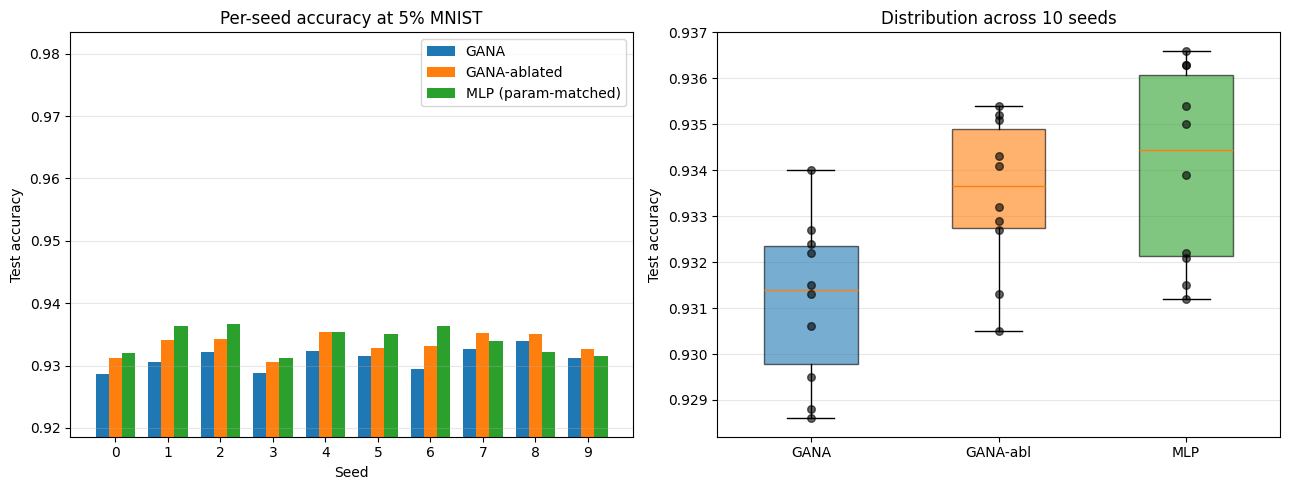

In [7]:
# Plot: per-seed accuracy + summary box/violin
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(SEEDS))
w = 0.25
ax1.bar(x - w, results['gana'], w, label='GANA', color='C0')
ax1.bar(x, results['gana_abl'], w, label='GANA-ablated', color='C1')
ax1.bar(x + w, results['mlp'], w, label='MLP (param-matched)', color='C2')
ax1.set_xlabel('Seed'); ax1.set_ylabel('Test accuracy')
ax1.set_title(f'Per-seed accuracy at {int(FRACTION*100)}% MNIST')
ax1.set_xticks(x); ax1.legend()
ax1.set_ylim(min(min(results['gana']), min(results['gana_abl']), min(results['mlp'])) - 0.01, None)
ax1.grid(alpha=0.3, axis='y')

data_for_box = [results['gana'], results['gana_abl'], results['mlp']]
bp = ax2.boxplot(data_for_box, labels=['GANA', 'GANA-abl', 'MLP'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['C0', 'C1', 'C2']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
for i, vals in enumerate(data_for_box):
    ax2.scatter([i+1]*len(vals), vals, color='black', alpha=0.6, s=30, zorder=3)
ax2.set_ylabel('Test accuracy')
ax2.set_title('Distribution across 10 seeds')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_multiseed.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
output = {
    'config': {'fraction': FRACTION, 'epochs': EPOCHS, 'seeds': SEEDS,
                'gana_params': count_params(GANAModel()), 'mlp_params': count_params(MLPBaseline())},
    'per_seed_accuracy': results,
    'summary': summ,
    'statistical_tests': tests,
}
with open('multiseed_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print(json.dumps(output, indent=2))

!zip multiseed_results.zip fig_multiseed.png multiseed_results.json
from google.colab import files
files.download('multiseed_results.zip')

{
  "config": {
    "fraction": 0.05,
    "epochs": 15,
    "seeds": [
      0,
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9
    ],
    "gana_params": 241290,
    "mlp_params": 247046
  },
  "per_seed_accuracy": {
    "gana": [
      0.9286,
      0.9306,
      0.9322,
      0.9288,
      0.9324,
      0.9315,
      0.9295,
      0.9327,
      0.934,
      0.9313
    ],
    "gana_abl": [
      0.9313,
      0.9341,
      0.9343,
      0.9305,
      0.9354,
      0.9329,
      0.9332,
      0.9352,
      0.9351,
      0.9327
    ],
    "mlp": [
      0.9321,
      0.9363,
      0.9366,
      0.9312,
      0.9354,
      0.935,
      0.9363,
      0.9339,
      0.9322,
      0.9315
    ]
  },
  "summary": {
    "gana": {
      "mean": 0.93116,
      "std": 0.0017758878843490789,
      "min": 0.9286,
      "max": 0.934,
      "n": 10
    },
    "gana_abl": {
      "mean": 0.93347,
      "std": 0.0016660332129542653,
      "min": 0.9305,
      "max": 0.935

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How to read this

**The headline number is `gana_vs_mlp` wins.** That's the Phase 1 claim being tested directly.

- 8-10 wins, p < 0.05 -> Phase 1 effect is real and significant. Project proceeds.
- 6-7 wins, p > 0.05 -> Effect is small/noisy. Need more seeds or bigger experiments to nail it down.
- 4-6 wins -> Phase 1 wins were seed luck. Project needs to pivot.

**The secondary number is `gana_vs_abl`.** That tells us whether curvature contributes anything at low data.
- If GANA beats ablated -> curvature does real work in low-data regimes (despite tying at full data)
- If GANA ~= ablated -> the positions parameter alone is the mechanism, curvature is decorative

**The third number, `abl_vs_mlp`,** tells us whether just having the positions parameter (without curvature) is enough to beat MLP.
- If yes -> the architecture wins from parameters, not dynamics. Simpler story for the paper.
- If no -> something about curvature matters at low data even if it's not geometric organization.